# Random Sample + Collate + Spectrogram
This cell pair picks a random local LibriSpeech sample, applies `collate_fn`, and visualizes the resulting mel spectrogram.

In [1]:
import matplotlib.pyplot as plt
import torch
import torchaudio
from torch.utils.data import DataLoader
from model.helpers import collate_fn_speed_perturb, collate_fn_cutout, blank, idx2char, get_dataset_lengths, BucketBatchSampler, collate_fn

import os
from dotenv import load_dotenv

load_dotenv()
root = str(os.getenv("ROOT"))

train_ds = torchaudio.datasets.LIBRISPEECH(root=root, url="test-clean", download=False)

print("Pre-computing lengths...")
train_lengths = get_dataset_lengths(train_ds)
train_sampler = BucketBatchSampler(train_lengths, batch_size=64, shuffle=True)

train_loader = DataLoader(train_ds, batch_sampler=train_sampler, collate_fn=collate_fn_cutout,
                          num_workers=4, pin_memory=True)

batch = next(iter(train_loader))
spectrogram_batch, targets_batch, input_lengths, target_lengths = batch



Pre-computing lengths...


Batch size: 64
Sample 62 | true frames: 913 | padded shape: (64, 919)
Input lengths in this batch: [892, 908, 895, 918, 891, 875, 893, 905, 874, 893, 887, 919, 905, 885, 915, 895, 879, 881, 899, 897, 892, 904, 874, 880, 900, 879, 888, 916, 881, 890, 905, 874, 895, 898, 888, 911, 875, 880, 883, 883, 875, 895, 910, 894, 878, 875, 888, 895, 900, 887, 881, 888, 895, 913, 878, 901, 893, 887, 907, 896, 910, 883, 913, 916]


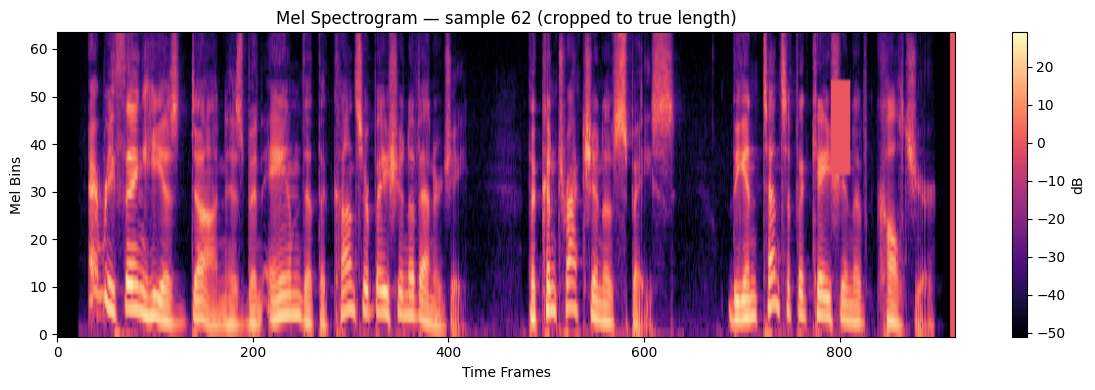

In [2]:
idx = torch.randint(0, len(spectrogram_batch), (1,)).item()
spec = spectrogram_batch[idx].cpu().numpy()
true_len = int(input_lengths[idx].item())

print(f"Batch size: {len(spectrogram_batch)}")
print(f"Sample {idx} | true frames: {true_len} | padded shape: {spec.shape}")
print(f"Input lengths in this batch: {input_lengths.tolist()}")

plt.figure(figsize=(12, 4))
plt.imshow(spec[:, :], aspect="auto", origin="lower", cmap="magma")
plt.title(f"Mel Spectrogram — sample {idx} (cropped to true length)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()
